In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# 1. By using the appropriate NetworkX function, find the maximum clique of the graph

In [3]:
pandemic_graph_us=nx.read_graphml('pandemic_board_us.graphml')

In [4]:
print(f'Max clique = {nx.approximation.max_clique(pandemic_graph_us)}')
print(f'The size of max clique = {nx.approximation.max_clique(pandemic_graph_us).__sizeof__()}')

Max clique = {'New York', 'Boston', 'Montréal'}
The size of max clique = 200


# 2. Download the file ”pandemic_europe.graphml” on UniversiTICE, and load the graph stored in this file

In [5]:
pandemic_graph_ue=nx.read_graphml('pandemic_europe.graphml')

# Determine if both graphs could be isomorphic or not using the Weisfeiler-Lehman test. If the result is positive, determine if they are isomorphic, and print the possible mapping

In [6]:
h1=nx.weisfeiler_lehman_graph_hash(pandemic_graph_us)
h2=nx.weisfeiler_lehman_graph_hash(pandemic_graph_ue)
if h1 != h2:
        print("Graphs are NOT isomorphic.")
else:

    print("Graphs could be isomorphic.")

Graphs are NOT isomorphic.


/home/souna/Bureau/Master2/ML_on_graph/.venv/lib/python3.12/site-packages/networkx/algorithms/graph_hashing.py:211: UserWarning: The hashes produced for graphs without node or edge attributeschanged in v3.5 due to a bugfix (see documentation).
  node_labels = _init_node_labels(G, edge_attr, node_attr)


## <font color='green'>The graphs are not isomorphics because thes hash values are diffenrent . It's correct because theye aren't the same number of edges</font>

## 4. Extract the subgraph induced by nodes ”Wien”, ”Budapest”, ”Sofia”, ”Athina”, ”Roma” in the ”Pandemic Europe” network, and call it H_europe. Find and print the automorphism of this subgraph

In [7]:
def show(G,tilte):
    pos = nx.spring_layout(G, seed=42, k=0.6) 

    plt.figure(figsize=(10, 4))
    nx.draw_networkx_nodes(G, pos, node_size=1200, edgecolors="black", linewidths=1.5)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
    nx.draw_networkx_edges(G, pos, width=2, alpha=0.4)
    plt.title(tilte, fontsize=14)
    plt.axis("off")
    plt.show()

In [8]:
H_europe=pandemic_graph_ue.subgraph(['Wien', 'Budapest', 'Sofia', 'Athina', 'Roma' ])
H_auto = nx.algorithms.isomorphism.GraphMatcher(H_europe,H_europe)
automorph = list(H_auto.isomorphisms_iter())
automorph

[{'Sofia': 'Sofia',
  'Athina': 'Athina',
  'Roma': 'Roma',
  'Wien': 'Wien',
  'Budapest': 'Budapest'},
 {'Wien': 'Sofia',
  'Roma': 'Athina',
  'Athina': 'Roma',
  'Sofia': 'Wien',
  'Budapest': 'Budapest'}]

## 5. Find all the subgraph isomorphisms of the subgraph extracted previously with the graph of the ”Pandemic North America” network. Print all the mappings provided by these isomorphisms

In [22]:
iso=nx.algorithms.isomorphism.GraphMatcher(pandemic_graph_us,H_europe)
iso_graph=list(iso.subgraph_isomorphisms_iter())
iso_graph

[{'Calgary': 'Sofia',
  'Seattle': 'Athina',
  'San Francisco': 'Roma',
  'Denver': 'Wien',
  'Minneapolis': 'Budapest'},
 {'Denver': 'Sofia',
  'San Francisco': 'Athina',
  'Seattle': 'Roma',
  'Calgary': 'Wien',
  'Minneapolis': 'Budapest'},
 {'Dallas': 'Sofia',
  'New Orleans': 'Athina',
  'Miami': 'Roma',
  'Atlanta': 'Wien',
  'Indianapolis': 'Budapest'},
 {'Toronto': 'Sofia',
  'Chicago': 'Athina',
  'Washington': 'Roma',
  'New York': 'Wien',
  'Montréal': 'Budapest'},
 {'New York': 'Sofia',
  'Washington': 'Athina',
  'Chicago': 'Roma',
  'Toronto': 'Wien',
  'Montréal': 'Budapest'},
 {'Indianapolis': 'Sofia',
  'Chicago': 'Athina',
  'Washington': 'Roma',
  'Atlanta': 'Wien',
  'Dallas': 'Budapest'},
 {'Atlanta': 'Sofia',
  'Washington': 'Athina',
  'Chicago': 'Roma',
  'Indianapolis': 'Wien',
  'Dallas': 'Budapest'},
 {'Atlanta': 'Sofia',
  'Miami': 'Athina',
  'New Orleans': 'Roma',
  'Dallas': 'Wien',
  'Indianapolis': 'Budapest'},
 {'Monterrey': 'Sofia',
  'Phoenix': 'Athi

## 6. Extract one of the subraphs of the ”Pandemic North America” network found as isomorphic in the previous question,and call it H_usa

In [30]:
H_usa=pandemic_graph_us.subgraph(iso_graph[0]).copy()
H_usa

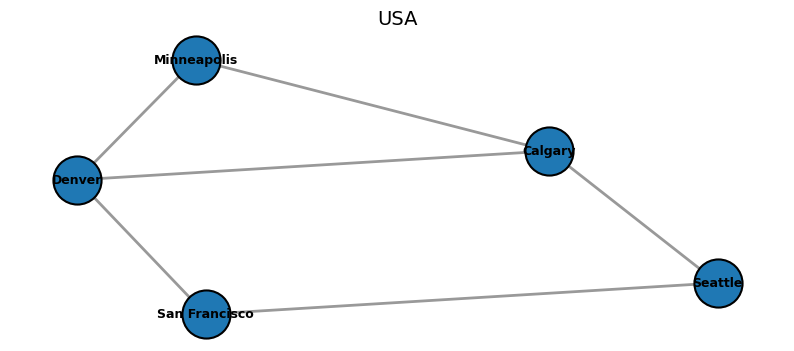

In [34]:
show(H_usa,'USA')

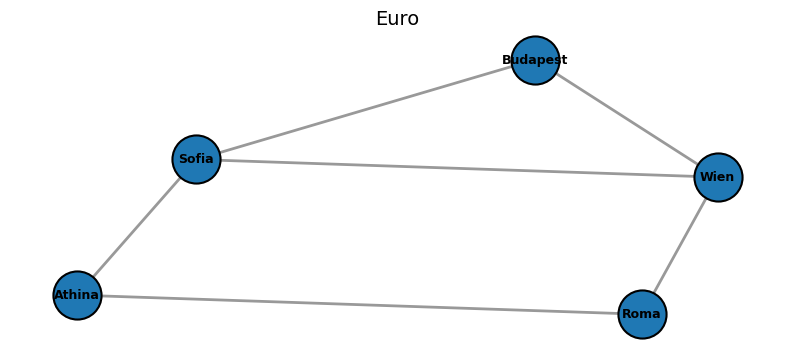

In [35]:
show(H_europe,'Euro')

In [47]:
A_H_usa=nx.to_numpy_array(H_usa)

In [91]:

H_iso=nx.algorithms.isomorphism.GraphMatcher(H_europe,H_usa)
if H_iso.is_isomorphic():
    mapping = H_iso.mapping 
    print("Mapping Ok:", mapping)
else:
    print("Les graphes ne sont pas isomorphes\n")


nodes_Eur = list(H_europe.nodes())
nodes_usa = list(H_usa.nodes())


n1 = len(nodes_Eur)
n2 = len(nodes_usa)
P = np.zeros((n1, n2))

for i, node_Eur in enumerate(nodes_Eur):
    nod_usa = mapping[node_Eur]
    j = nodes_usa.index(nod_usa)
    P[i, j] = 1

print("Matrice de permutation P :\n", P)


Mapping Ok: {'Sofia': 'Denver', 'Wien': 'Calgary', 'Athina': 'San Francisco', 'Budapest': 'Minneapolis', 'Roma': 'Seattle'}
Matrice de permutation P :
 [[1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]


In [ ]:

A_H_usa = nx.to_numpy_array(H_usa)

In [94]:
# Verifion A_H_Europe

A_H_Europe=P@A_H_usa@P.T

In [96]:

nodes_order_eu = list(H_europe.nodes())
np.all(A_H_Europe==nx.to_numpy_array(H_europe))

np.True_